In [ ]:
# 116710400063-9 ภูมิพิพัฒน์ เยบุญ
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [12]:
# โหลดข้อมูล 1
df = pd.read_csv("student_data.csv")

# แสดงข้อมูล
print("===== Dataset =====")
print(df)

# ขนาดข้อมูล
print("\n===== Shape =====")
print(df.shape)

# ชนิดข้อมูล
print("\n===== Data Types =====")
print(df.dtypes)

# สถิติเบื้องต้น
print("\n===== Summary Statistics =====")
print(df.describe())

# ตรวจสอบ Missing Values
print("\n===== Missing Values =====")
print(df.isnull().sum())

# ตรวจสอบข้อมูลซ้ำ
print("\n===== Duplicate Records =====")
print(df.duplicated().sum())

# การกระจายของคลาส
print("\n===== Class Distribution =====")
print(df["Passed"].value_counts())

===== Dataset =====
   Study_Hours  Attendance Passed
0            1          60     No
1            2          70     No
2            3          75     No
3            4          80    Yes
4            5          85    Yes
5            6          90    Yes
6            2          65     No
7            3          78    Yes
8            4          82    Yes
9            5          88    Yes

===== Shape =====
(10, 3)

===== Data Types =====
Study_Hours    int64
Attendance     int64
Passed           str
dtype: object

===== Summary Statistics =====
       Study_Hours  Attendance
count    10.000000   10.000000
mean      3.500000   77.300000
std       1.581139    9.855061
min       1.000000   60.000000
25%       2.250000   71.250000
50%       3.500000   79.000000
75%       4.750000   84.250000
max       6.000000   90.000000

===== Missing Values =====
Study_Hours    0
Attendance     0
Passed         0
dtype: int64

===== Duplicate Records =====
0

===== Class Distribution =====
Passed
Yes

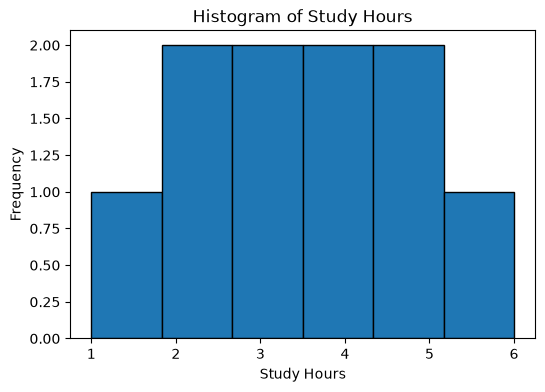

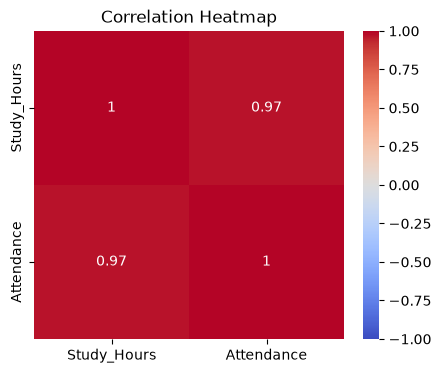

In [13]:
# =========================
# Histogram
# =========================
plt.figure(figsize=(6,4))
plt.hist(df["Study_Hours"], bins=6, edgecolor="black")
plt.title("Histogram of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

# =========================
# Correlation Heatmap
# =========================
# เลือกเฉพาะคอลัมน์ตัวเลข
numeric_df = df[["Study_Hours", "Attendance"]]

# คำนวณ Correlation
corr = numeric_df.corr()

# วาด Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
print("ข้อมูลก่อนทำความสะอาด")
print(df)

# 1. Missing Value Handling
df["Attendance"] = pd.to_numeric(df["Attendance"], errors="coerce")
df["Attendance"].fillna(df["Attendance"].mean(), inplace=True)

# 2. Duplicate Removal
df = df.drop_duplicates()

# 3. Incorrect Data Correction
df["Passed"] = df["Passed"].replace({"YES":"Yes","NO":"No"})

# 4. Data Type Conversion
df["Study_Hours"] = df["Study_Hours"].astype(int)
df["Attendance"] = df["Attendance"].astype(float)

print("\nข้อมูลหลังทำความสะอาด")
print(df)

# Mean และ Median
print("\nMean")
print(df[["Study_Hours","Attendance"]].mean())

print("\nMedian")
print(df[["Study_Hours","Attendance"]].median())

ข้อมูลก่อนทำความสะอาด
   Study_Hours  Attendance Passed
0            1          60     No
1            2          70     No
2            3          75     No
3            4          80    Yes
4            5          85    Yes
5            6          90    Yes
6            2          65     No
7            3          78    Yes
8            4          82    Yes
9            5          88    Yes

ข้อมูลหลังทำความสะอาด
   Study_Hours  Attendance Passed
0            1        60.0     No
1            2        70.0     No
2            3        75.0     No
3            4        80.0    Yes
4            5        85.0    Yes
5            6        90.0    Yes
6            2        65.0     No
7            3        78.0    Yes
8            4        82.0    Yes
9            5        88.0    Yes

Mean
Study_Hours     3.5
Attendance     77.3
dtype: float64

Median
Study_Hours     3.5
Attendance     79.0
dtype: float64


C:\Users\beamp\AppData\Local\Temp\ipykernel_22304\450553291.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Attendance"].fillna(df["Attendance"].mean(), inplace=True)


In [15]:
# โหลดข้อมูล
df = pd.read_csv("student_data.csv")

# -------------------------
# Data Cleaning (เหมือน Part 3)
# -------------------------
df["Attendance"] = pd.to_numeric(df["Attendance"], errors="coerce")
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df = df.drop_duplicates()
df["Passed"] = df["Passed"].replace({"YES": "Yes", "NO": "No"})

# -------------------------
# Label Encoding
# -------------------------
le = LabelEncoder()
df["Passed_Label"] = le.fit_transform(df["Passed"])

print("Label Encoding")
print(df[["Passed", "Passed_Label"]])

# -------------------------
# One-Hot Encoding
# -------------------------
onehot = pd.get_dummies(df["Passed"], prefix="Passed")

print("\nOne-Hot Encoding")
print(onehot)

Label Encoding
  Passed  Passed_Label
0     No             0
1     No             0
2     No             0
3    Yes             1
4    Yes             1
5    Yes             1
6     No             0
7    Yes             1
8    Yes             1
9    Yes             1

One-Hot Encoding
   Passed_No  Passed_Yes
0       True       False
1       True       False
2       True       False
3      False        True
4      False        True
5      False        True
6       True       False
7      False        True
8      False        True
9      False        True
